## Import Library and Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

df = pd.read_csv("ecommerce_500k.csv")

print(f"Dataset contains {df.shape[0]} rows and {df.shape[1]} columns.")

df.head()

Dataset contains 500000 rows and 30 columns.


,order_id,customer_id,product_id,order_date,category,sub_category,product_base_price,discount_percentage,final_price,quantity,...,city,loyalty_tier,is_first_purchase,customer_lifetime_value,session_duration_mins,pages_viewed,clicks_to_purchase,is_returned,return_reason,is_cancelled
0,1000001,25795,90,2022-07-31,Clothing,Men,70.41,25,52.81,1,...,Bangalore,Bronze,0,457.77,4.6,35.0,7,0,NaN,0
1,1000002,10860,1917,2023-09-25,Automotive,Car Care,6.02,10,5.42,3,...,Toronto,Bronze,0,1606.42,2.9,8.0,8,0,NaN,0
2,1000003,86820,805,2022-03-26,Books,Textbooks,78.85,20,63.08,2,...,Chicago,Silver,0,252.16,5.5,38.0,8,0,NaN,0
3,1000004,64886,3379,2022-11-03,Books,Non-Fiction,58.42,25,43.82,4,...,Sydney,Bronze,0,645.12,6.1,30.0,9,0,NaN,0
4,1000005,16265,4604,2022-06-30,Clothing,Women,73.38,15,62.37,1,...,Manchester,Bronze,1,1103.24,1.6,38.0,11,0,NaN,0


## Phase 1: The manager says "audit the data first." Where do you even begin?

In [3]:
df.info()

print("Total Duplicate Rows:", df.duplicated().sum())

missing_report = pd.DataFrame({
    "Missing Values": df.isnull().sum()
})

missing_report = missing_report[missing_report["Missing Values"] > 0]

missing_report.sort_values(
    by="Missing Values",
    ascending=False
)

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 30 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   order_id                 500000 non-null  int64  
 1   customer_id              500000 non-null  int64  
 2   product_id               500000 non-null  int64  
 3   order_date               500000 non-null  str    
 4   category                 500000 non-null  str    
 5   sub_category             500000 non-null  str    
 6   product_base_price       500000 non-null  float64
 7   discount_percentage      500000 non-null  int64  
 8   final_price              500000 non-null  float64
 9   quantity                 500000 non-null  int64  
 10  total_amount             500000 non-null  float64
 11  shipping_cost            484934 non-null  float64
 12  shipping_method          500000 non-null  str    
 13  days_to_deliver          484751 non-null  float64
 14  payment_method 

,Missing Values
return_reason,440096
days_to_deliver,15249
shipping_cost,15066
customer_lifetime_value,15004
rating,14990
customer_age,14928
pages_viewed,14814
session_duration_mins,14725


## Phase 2: Someone suspects the pricing data is heavily skewed — prove it or disprove it.


product_base_price: 2.0084
final_price: 2.1078
total_amount: 4.3841
shipping_cost: 1.9874


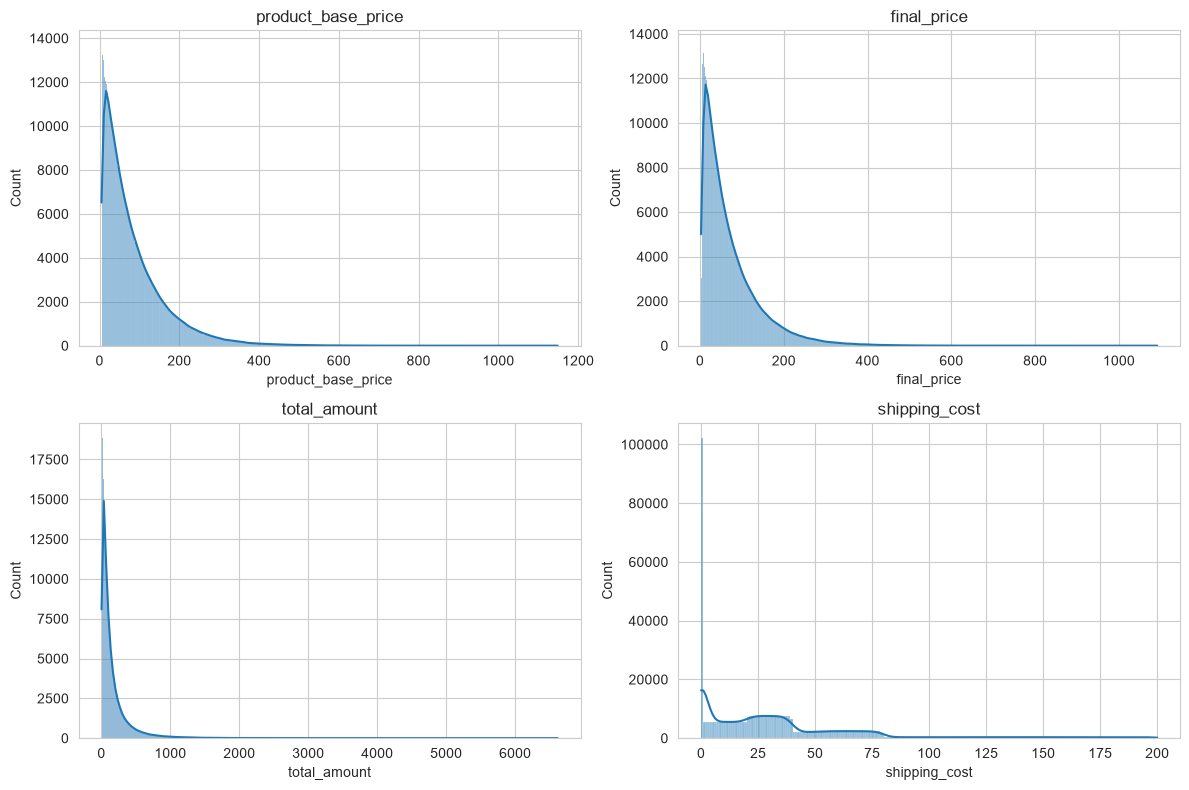

,count,mean,std,min,90%,95%,99%,max
product_base_price,500000.0,84.833241,79.984198,5.0,188.980,244.350,373.9400,1148.77
final_price,500000.0,72.438608,69.900582,2.5,162.210,211.270,329.5501,1091.33
total_amount,500000.0,165.605507,237.412198,2.5,390.302,582.681,1175.0904,6617.30
shipping_cost,484934.0,34.031570,39.185919,0.0,75.860,125.580,184.8300,200.00


In [4]:
price_columns = [
    "product_base_price",
    "final_price",
    "total_amount",
    "shipping_cost"
]

for column in price_columns:
    print(f"{column}: {df[column].skew():.4f}")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, column in enumerate(price_columns):
    sns.histplot(
        df[column].dropna(),
        kde=True,
        ax=axes.flat[i]
    )

    axes.flat[i].set_title(column)

plt.tight_layout()
plt.show()

df[price_columns].describe(
    percentiles=[0.90, 0.95, 0.99]
).T

## Phase 3: Which categorical columns will break your ML pipeline if left untouched?

In [5]:
categorical_columns = df.select_dtypes(
    include="object"
).columns

for column in categorical_columns:
    unique_count = df[column].nunique()

    print(
        f"{column}: {unique_count} unique values"
    )

print("\nOrder Date Samples:")
print(df["order_date"].head())

print("\nCity Samples:")
print(df["city"].head())

order_date: 1095 unique values
category: 10 unique values
sub_category: 45 unique values
shipping_method: 4 unique values
payment_method: 6 unique values
customer_gender: 3 unique values
country: 8 unique values
city: 15 unique values
loyalty_tier: 4 unique values
return_reason: 5 unique values

Order Date Samples:
0    2022-07-31
1    2023-09-25
2    2022-03-26
3    2022-11-03
4    2022-06-30
Name: order_date, dtype: str

City Samples:
0     Bangalore
1       Toronto
2       Chicago
3        Sydney
4    Manchester
Name: city, dtype: str


## Phase 4: Why are customers returning products? Find the patterns that matter to the business.

In [6]:
print(
    "Overall Return Rate:",
    round(
        df["is_returned"].mean() * 100,
        2
    ),
    "%"
)

columns = [
    "category",
    "shipping_method",
    "loyalty_tier",
    "customer_gender",
    "payment_method"
]

for column in columns:

    print(f"\n{column}")

    display(
        df.groupby(column)["is_returned"]
        .mean()
        .sort_values(
            ascending=False
        ) * 100
    )

print("\nis_cancelled")

display(
    df.groupby("is_cancelled")[
        "is_returned"
    ].mean() * 100
)

print("\nReturn Reasons")

df["return_reason"].value_counts(
    dropna=False
)

Overall Return Rate: 11.98 %

category


category
Electronics       12.113895
Furniture         12.098325
Beauty            12.057121
Automotive        12.047492
Books             12.041990
Toys              11.942231
Food & Grocery    11.932297
Home & Kitchen    11.894722
Sports            11.864271
Clothing          11.819116
Name: is_returned, dtype: float64


shipping_method


shipping_method
Express     12.003078
Standard    11.998508
Free        11.968165
Same-Day    11.870934
Name: is_returned, dtype: float64


loyalty_tier


...

payment_method
Wallet         12.052046
COD            12.035979
UPI            12.028366
Credit Card    12.005766
Net Banking    11.878894
Debit Card     11.861737
Name: is_returned, dtype: float64


is_cancelled


is_cancelled
0    12.768107
1     0.000000
Name: is_returned, dtype: float64


Return Reasons


return_reason
NaN                   440096
Not as Described       12080
Defective              12047
Wrong Item             11962
Better Price Found     11933
Changed Mind           11882
Name: count, dtype: int64

## Phase 5: Build the full ColumnTransformer pipeline — different scalers for different columns, handle missings, encode categoricals.


In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    OrdinalEncoder,
    TargetEncoder
)

y = df["is_returned"]

num_cols = [
    "product_base_price",
    "discount_percentage",
    "final_price",
    "quantity",
    "total_amount",
    "shipping_cost",
    "days_to_deliver",
    "rating",
    "num_reviews",
    "customer_age",
    "customer_lifetime_value",
    "session_duration_mins",
    "pages_viewed",
    "clicks_to_purchase"
]

cat_cols = [
    "category",
    "sub_category",
    "shipping_method",
    "payment_method",
    "customer_gender",
    "country"
]

high_card_cols = ["city"]

ordinal_cols = ["loyalty_tier"]

binary_cols = [
    "is_first_purchase",
    "is_cancelled"
]

X = df[
    num_cols +
    cat_cols +
    high_card_cols +
    ordinal_cols +
    binary_cols
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    (
        "encoder",
        OrdinalEncoder(
            categories=[
                ["Bronze", "Silver", "Gold", "Platinum"]
            ]
        )
    )
])

city_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", TargetEncoder(random_state=42))
])

binary_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols),
    ("ord", ordinal_pipeline, ordinal_cols),
    ("city", city_pipeline, high_card_cols),
    ("bin", binary_pipeline, binary_cols)
])

X_processed = preprocessor.fit_transform(X, y)

print("Processed Shape:", X_processed.shape)

Processed Shape: (500000, 94)


## Phase 6: CAre any features too correlated with each other? Which ones actually predict returns?


Highly Correlated Features
['final_price', 'product_base_price', np.float64(0.976)]
['total_amount', 'product_base_price', np.float64(0.66)]
['total_amount', 'final_price', np.float64(0.675)]
['total_amount', 'quantity', np.float64(0.531)]


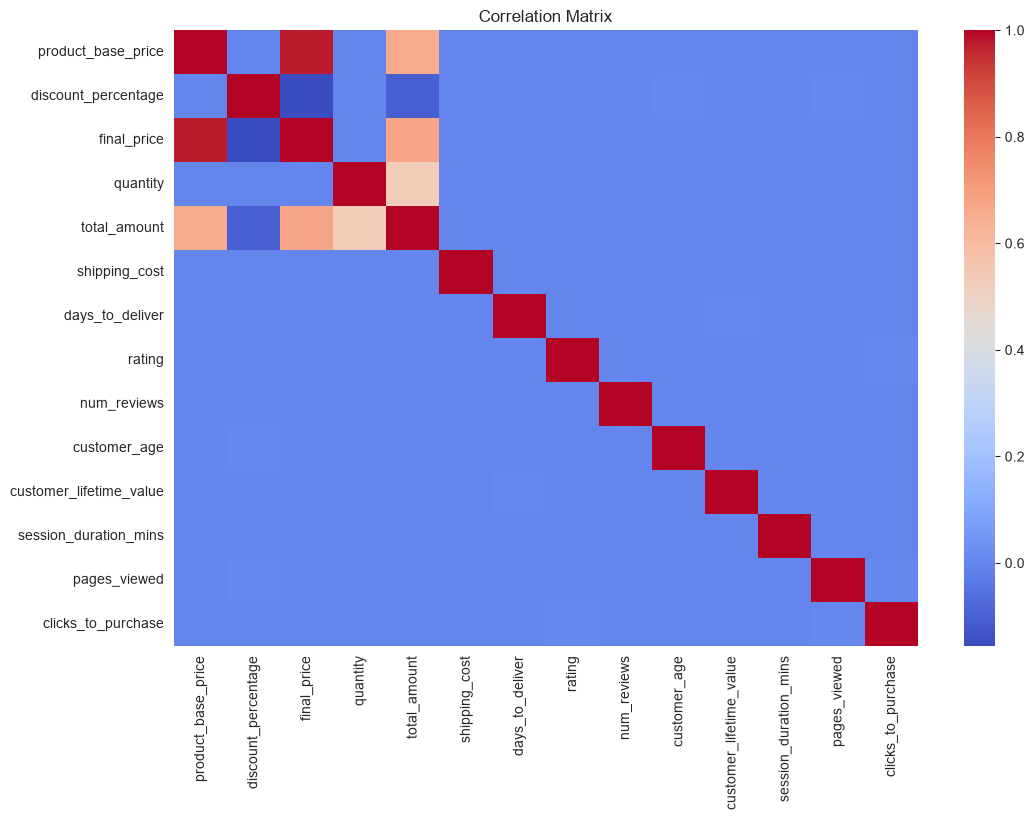

In [8]:
corr_matrix = df[num_cols].corr()

high_corr = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        corr_value = corr_matrix.iloc[i, j]

        if abs(corr_value) > 0.5:
            high_corr.append([
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                round(corr_value, 3)
            ])

print("Highly Correlated Features")

for item in high_corr:
    print(item)

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y,
    test_size=0.2,
    random_state=42
)

lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(
    X_train,
    y_train
)

print(
    "Logistic Regression Accuracy:",
    round(
        lr_model.score(
            X_test,
            y_test
        ) * 100,
        2
    ),
    "%"
)

Logistic Regression Accuracy: 88.09 %


In [10]:
tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree_model.fit(
    X_train,
    y_train
)

print(
    "Decision Tree Accuracy:",
    round(
        tree_model.score(
            X_test,
            y_test
        ) * 100,
        2
    ),
    "%"
)

Decision Tree Accuracy: 88.08 %


In [11]:
cat_encoder = (
    preprocessor
    .named_transformers_["cat"]
    .named_steps["encoder"]
)

cat_names = cat_encoder.get_feature_names_out(
    cat_cols
).tolist()

feature_names = (
    num_cols +
    cat_names +
    ordinal_cols +
    high_card_cols +
    binary_cols
)

importance = pd.Series(
    tree_model.feature_importances_,
    index=feature_names
).sort_values(
    ascending=False
)

importance.head(10)

is_cancelled               0.945905
total_amount               0.011083
session_duration_mins      0.008491
customer_age               0.006146
customer_lifetime_value    0.005959
product_base_price         0.004341
clicks_to_purchase         0.003851
sub_category_Footwear      0.003732
final_price                0.003679
discount_percentage        0.003553
dtype: float64

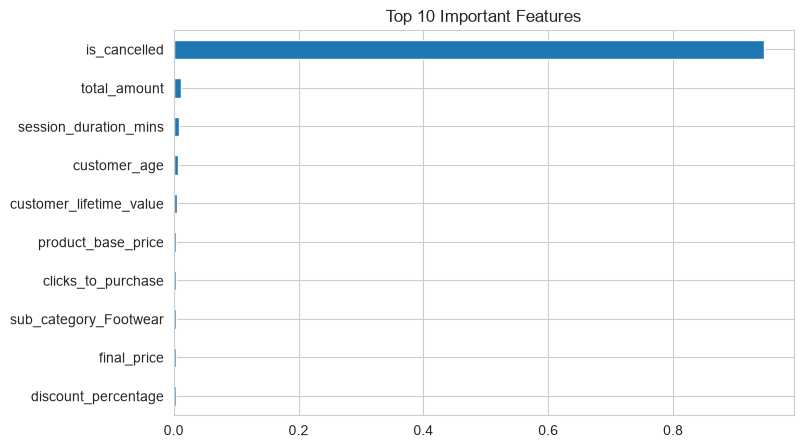

In [12]:
importance.head(10).sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.title("Top 10 Important Features")
plt.show()

## ADITYA VARSHNEY